<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 4. Mejorar la Generalización en modelos</font></h1>

<h1><font color="#113D68" size=4>10. Visualizar el modelo
</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Representación gráfica en PyTorch](#section1)
* [2. Netron para crear un gráfico del modelo](#section2)
* [3. Visualización con Torchviz](#section3)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

PyTorch es una biblioteca de aprendizaje profundo. Puedes construir modelos de aprendizaje profundo muy sofisticados con PyTorch. Sin embargo, hay momentos en los que deseas tener una representación gráfica de la arquitectura de tu modelo. En esta clase, aprenderás:

- Cómo guardar tu modelo de PyTorch en un formato de intercambio
- Cómo usar Netron para crear una representación gráfica.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch tutorials.](https://pytorch.org/tutorials/)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch Documentation: [`torch.utils.data`](https://pytorch.org/docs/stable/data.html)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch Documentation: [`torch.utils.checkpoint`](https://pytorch.org/docs/stable/checkpoint.html)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1.  Representación gráfica en PyTorch</font>

- Desafío:
  - Dificultad para entender el funcionamiento interno del modelo

  - No es trivial convertir un modelo PyTorch en una imagen

- Soluciones para visualización:
  1. Seguir el tensor en la pasada hacia adelante

     - Observar las operaciones (capas) aplicadas

  2. Seguir el tensor en la pasada hacia atrás

     - Ver cómo se propaga el gradiente hacia la entrada

- Herramienta recomendada: **ONNX**

  - Facilita la visualización de modelos PyTorch

- Proceso general:
  1. Convertir el modelo PyTorch a formato ONNX
  2. Utilizar herramientas de visualización ONNX

- Ventajas de usar ONNX:
  - Proporciona una representación estandarizada del modelo

  - Facilita la interoperabilidad entre diferentes frameworks

- Consideraciones:
  - La visualización puede ser limitada para modelos muy complejos

  - Algunas operaciones personalizadas pueden no ser compatibles con ONNX

- Pasos típicos para visualizar:
  1. Definir un tensor de entrada de ejemplo

  2. Exportar el modelo a ONNX

  3. Usar herramientas como Netron para visualizar el grafo ONNX

In [ ]:
!pip install -q onnx onnxscript  # torch.onnx.export (exportador moderno) necesita onnxscript

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Netron para crear un gráfico del modelo</font>

Esta aproximación permite superar las limitaciones de visualización de los modelos PyTorch, facilitando su análisis y comprensión a través de herramientas como Netron.

- Guardado de modelos PyTorch:
  - Se guardan los estados del modelo

  - Accesibles mediante `model.state_dict()`

- Visualización de modelos PyTorch:
  - Pocas herramientas disponibles

  - Herramienta recomendada: Netron

- Características de Netron:
  - "Visor de modelos de aprendizaje profundo"

  - Disponible para macOS, Linux y Windows

  - Versión en línea para subir archivos de modelo

- Limitación de Netron con PyTorch:
  - No puede visualizar directamente desde estados guardados

- Solución: Conversión a formato ONNX

  - PyTorch permite convertir modelos a ONNX

  - Netron puede interpretar y visualizar modelos ONNX

- Proceso general:
  1. Convertir modelo PyTorch a ONNX
  
  2. Utilizar Netron para visualizar el modelo ONNX


<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [Netron Releases](https://github.com/lutzroeder/netron/releases)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Versión online de [Netron Releases](https://netron.app/)


Comencemos con un ejemplo. A continuación, creaste un modelo simple para clasificar el conjunto de datos de iris. Es un problema de clasificación con tres clases. Por lo tanto, el modelo debería devolver un vector de tres valores. Un código completo que crearías para este problema es el siguiente, el cual obtiene el conjunto de datos de scikit-learn:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data['data']
y = data['target']
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

class IrisModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

model = IrisModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
batch_size = 10
batch_start = torch.arange(0, len(X_train), batch_size)

for epoch in range(n_epochs):
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

y_pred = model(X_test)
acc = (torch.argmax(y_pred, 1) == y_test).float().mean()
acc = float(acc)*100
print("Model accuracy: %.2f%%" % acc)


Model accuracy: 91.11%


Así que sabes que el modelo es un modelo de PyTorch que puede tomar un tensor y devolver un tensor. 

Convertimos este modelo al formato ONNX usando la función `torch.onnx.export()`:

In [2]:
torch.onnx.export(model, X_test, 'iris.onnx', input_names=['features'], output_names=['logits'])

- Creación del archivo ONNX:
  - Ejecutar el código genera `iris.onnx` en el directorio local

- Requerimientos para la conversión:
  - Proporcionar un tensor de muestra (ej. `X_test`)

  - Necesario para seguir las operaciones del modelo

- Nombramiento de tensores:
  - Tensores de entrada/salida generalmente sin nombre

  - Nombres deben proporcionarse en `export()`

  - Se usa una lista de cadenas para múltiples tensores

- Momento óptimo para `export()`:
  - Idealmente después del ciclo de entrenamiento

  - Para visualización, se puede hacer inmediatamente después de crear el modelo

- Visualización en Netron:
  - Abrir el archivo ONNX guardado

  - Muestra conexiones entre tensores de entrada y salida

  - Visualiza operaciones del modelo

- Detalles en la visualización:
  - Nombres de tensores de entrada/salida visibles

  - Clic en cajas para más detalles sobre tensores/operaciones

  - Nombres de operaciones pueden diferir de PyTorch (ej. `nn.Linear()` como "Gemm")

- Funcionalidades adicionales de Netron:
  - Examinar pesos de capas específicas

  - Exportar visualización en formato PNG
  
<center>
<figure>
  <img src="Datasets/iris_netron.png" width="350" height="250" alt="Netron">
  <figcaption><blockquote>Imagen obtenida por Netron</blockquote></figcaption>
</figure>
</center>

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>3. Visualización con Torchviz</font>

- Torchviz es un pequeño paquete para la visualizaición de modelos. 

- Es importante resaltar que tiene sus dependencias como el paquete `graphviz`. 

- Es por eso que según las instrucciones oficiales para MacOS se debe instalar este paquete previamente.

- Seguir las instrucciones de la web oficial

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [PyTorchViz](https://github.com/szagoruyko/pytorchviz)

Posteriormente instalamos el paquete

In [ ]:
!pip install torchviz

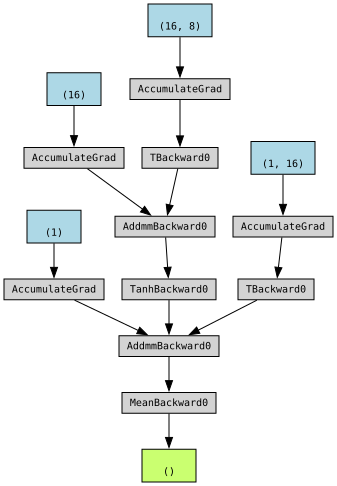

In [3]:
from torchviz import make_dot, make_dot_from_trace
import torch
import torch.nn as nn

model = nn.Sequential()
model.add_module('W0', nn.Linear(8, 16))
model.add_module('tanh', nn.Tanh())
model.add_module('W1', nn.Linear(16, 1))

x = torch.randn(1, 8)
y = model(x)
make_dot(y.mean())

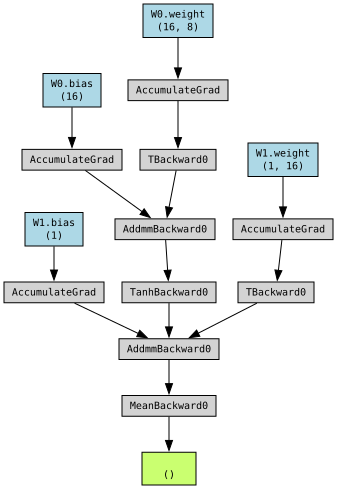

In [4]:

make_dot(y.mean(), params=dict(model.named_parameters()))


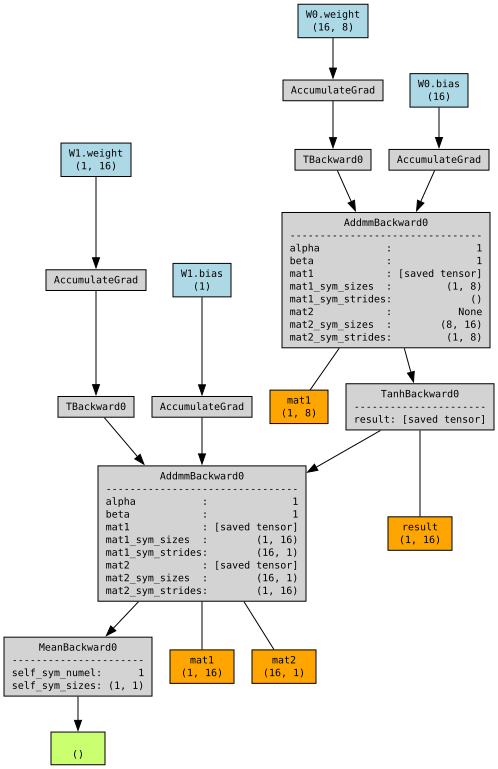

In [5]:
make_dot(y.mean(), params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>